# ✈️ Travel & Wellness Tourism — Complete EDA + ML Pipeline
> **Dataset:** Travel Product Purchase Prediction  
> **Target:** `ProdTaken` — whether a customer purchased a travel product  
> **Author:** Sankalp Satpute

---


In [33]:
# -- Core Libraries --
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# -- ML / Evaluation --
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                              accuracy_score, f1_score, precision_score, recall_score)
import joblib
import os

# -- Project Pipeline --
import prediction as pred

# -- Plot Style --
sns.set_theme(style='darkgrid', palette='husl')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'figure.figsize': (10, 5)})
PAL = ['#00D4FF','#7B61FF','#FF3CAC','#FFB547','#00E5A0','#4ECDC4','#FF6B6B']

print("[OK] Core libraries and prediction pipeline loaded successfully!")


[OK] Core libraries and prediction pipeline loaded successfully!


## 1. Data Loading & Basic Inspection

In [34]:
df = pd.read_csv('travel_dataset.csv')

print("=" * 65)
print(f"📐 Shape        : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print("=" * 65)
print("\n📋 Column dtypes:")
print(df.dtypes.to_string())
print("\n📊 First 5 rows:")
df.head()


📐 Shape        : 4,888 rows  ×  20 columns

📋 Column dtypes:
CustomerID                    int64
ProdTaken                     int64
Age                         float64
TypeofContact                object
CityTier                      int64
DurationOfPitch             float64
Occupation                   object
Gender                       object
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched               object
PreferredPropertyStar       float64
MaritalStatus                object
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                  object
MonthlyIncome               float64

📊 First 5 rows:


,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## 2. Data Quality — Missing Values, Duplicates, Cardinality

In [35]:
print("=" * 65)
print("❌ MISSING VALUES")
print("=" * 65)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Count': missing, 'Pct (%)': missing_pct})
print(miss_df[miss_df['Count'] > 0].sort_values('Count', ascending=False).to_string())

print(f"\n🔁 Duplicate rows : {df.duplicated().sum()}")

print("\n📦 Unique value counts per column:")
for col in df.columns:
    print(f"  {col:<30} {df[col].nunique():>4} unique | dtype: {df[col].dtype}")


❌ MISSING VALUES
                          Count  Pct (%)
DurationOfPitch             251     5.14
MonthlyIncome               233     4.77
Age                         226     4.62
NumberOfTrips               140     2.86
NumberOfChildrenVisiting     66     1.35
NumberOfFollowups            45     0.92
PreferredPropertyStar        26     0.53
TypeofContact                25     0.51

🔁 Duplicate rows : 0

📦 Unique value counts per column:
  CustomerID                     4888 unique | dtype: int64
  ProdTaken                         2 unique | dtype: int64
  Age                              44 unique | dtype: float64
  TypeofContact                     2 unique | dtype: object
  CityTier                          3 unique | dtype: int64
  DurationOfPitch                  34 unique | dtype: float64
  Occupation                        4 unique | dtype: object
  Gender                            3 unique | dtype: object
  NumberOfPersonVisiting            5 unique | dtype: int64
  NumberOf

## 3. Descriptive Statistics

In [36]:
print("📊 Numerical Summary:")
df.describe().round(2)


📊 Numerical Summary:


,CustomerID,ProdTaken,Age,CityTier,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,MonthlyIncome
count,4888.00,4888.00,4662.00,4888.00,4637.00,4888.00,4843.00,4862.00,4748.00,4888.00,4888.00,4888.00,4822.00,4655.00
mean,202443.50,0.19,37.62,1.65,15.49,2.91,3.71,3.58,3.24,0.29,3.08,0.62,1.19,23619.85
std,1411.19,0.39,9.32,0.92,8.52,0.72,1.00,0.80,1.85,0.45,1.37,0.49,0.86,5380.70
min,200000.00,0.00,18.00,1.00,5.00,1.00,1.00,3.00,1.00,0.00,1.00,0.00,0.00,1000.00
25%,201221.75,0.00,31.00,1.00,9.00,2.00,3.00,3.00,2.00,0.00,2.00,0.00,1.00,20346.00
50%,202443.50,0.00,36.00,1.00,13.00,3.00,4.00,3.00,3.00,0.00,3.00,1.00,1.00,22347.00
75%,203665.25,0.00,44.00,3.00,20.00,3.00,4.00,4.00,4.00,1.00,4.00,1.00,2.00,25571.00
max,204887.00,1.00,61.00,3.00,127.00,5.00,6.00,5.00,22.00,1.00,5.00,1.00,3.00,98678.00


In [37]:
print("🏷 Categorical Summary:")
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f"\n── {col} ──")
    print(df[col].value_counts(dropna=False).to_string())


🏷 Categorical Summary:

── TypeofContact ──
TypeofContact
Self Enquiry       3444
Company Invited    1419
NaN                  25

── Occupation ──
Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2

── Gender ──
Gender
Male       2916
Female     1817
Fe Male     155

── ProductPitched ──
ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230

── MaritalStatus ──
MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682

── Designation ──
Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230


## 4. Target Variable Analysis — `ProdTaken`

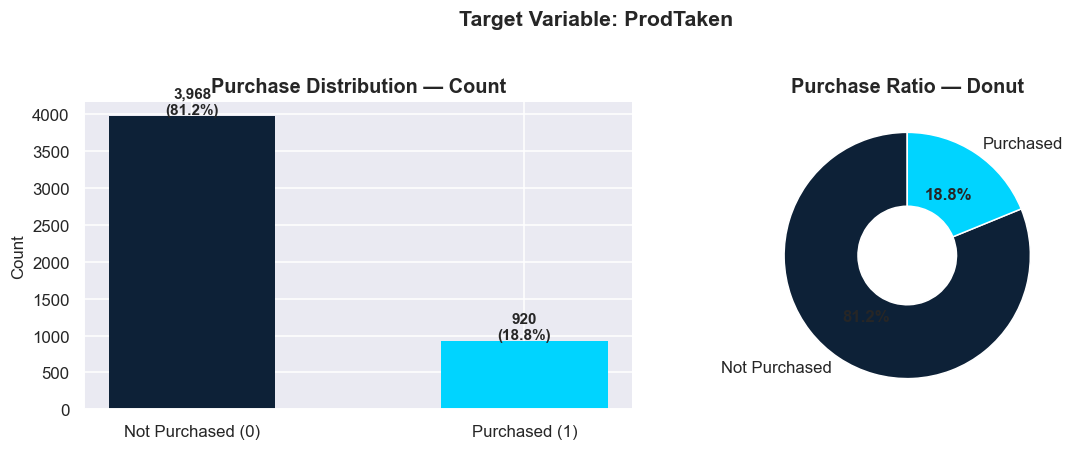

⚠️  Class imbalance ratio: 4.31 : 1


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
vc = df['ProdTaken'].value_counts()
bars = axes[0].bar(['Not Purchased (0)', 'Purchased (1)'], vc.values,
                   color=['#0D2137','#00D4FF'], edgecolor='none', width=0.5)
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Purchase Distribution — Count', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].spines[['top','right']].set_visible(False)

# Pie
wedges, texts, autotexts = axes[1].pie(
    vc.values, labels=['Not Purchased','Purchased'],
    autopct='%1.1f%%', startangle=90,
    colors=['#0D2137','#00D4FF'], wedgeprops=dict(width=0.6),
    textprops=dict(fontsize=11))
for at in autotexts: at.set_fontweight('bold')
axes[1].set_title('Purchase Ratio — Donut', fontweight='bold')

plt.suptitle('Target Variable: ProdTaken', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_target.png', dpi=110, bbox_inches='tight')
plt.show()

print(f"⚠️  Class imbalance ratio: {vc[0]/vc[1]:.2f} : 1")


## 5. Data Cleaning

In [39]:
dfc = df.copy()

# Fix known typo in Gender
dfc['Gender'] = dfc['Gender'].replace('Fe Male', 'Female')
print("✅ Fixed 'Fe Male' → 'Female'")
print("   Gender counts:", dfc['Gender'].value_counts().to_dict())

# Impute missing values
num_cols  = dfc.select_dtypes(include=['float64','int64']).columns.tolist()
cat_cols  = dfc.select_dtypes(include='object').columns.tolist()

for col in num_cols:
    if dfc[col].isnull().sum() > 0:
        median_val = dfc[col].median()
        dfc[col].fillna(median_val, inplace=True)
        print(f"✅ Imputed {col:<30} with median = {median_val:.2f}")

for col in cat_cols:
    if dfc[col].isnull().sum() > 0:
        mode_val = dfc[col].mode()[0]
        dfc[col].fillna(mode_val, inplace=True)
        print(f"✅ Imputed {col:<30} with mode  = {mode_val}")

print(f"\n🧹 Remaining missing values: {dfc.isnull().sum().sum()}")


✅ Fixed 'Fe Male' → 'Female'
   Gender counts: {'Male': 2916, 'Female': 1972}
✅ Imputed Age                            with median = 36.00
✅ Imputed DurationOfPitch                with median = 13.00
✅ Imputed NumberOfFollowups              with median = 4.00
✅ Imputed PreferredPropertyStar          with median = 3.00
✅ Imputed NumberOfTrips                  with median = 3.00
✅ Imputed NumberOfChildrenVisiting       with median = 1.00
✅ Imputed MonthlyIncome                  with median = 22347.00
✅ Imputed TypeofContact                  with mode  = Self Enquiry

🧹 Remaining missing values: 0


## 6. Outlier Detection & Treatment (IQR Method)

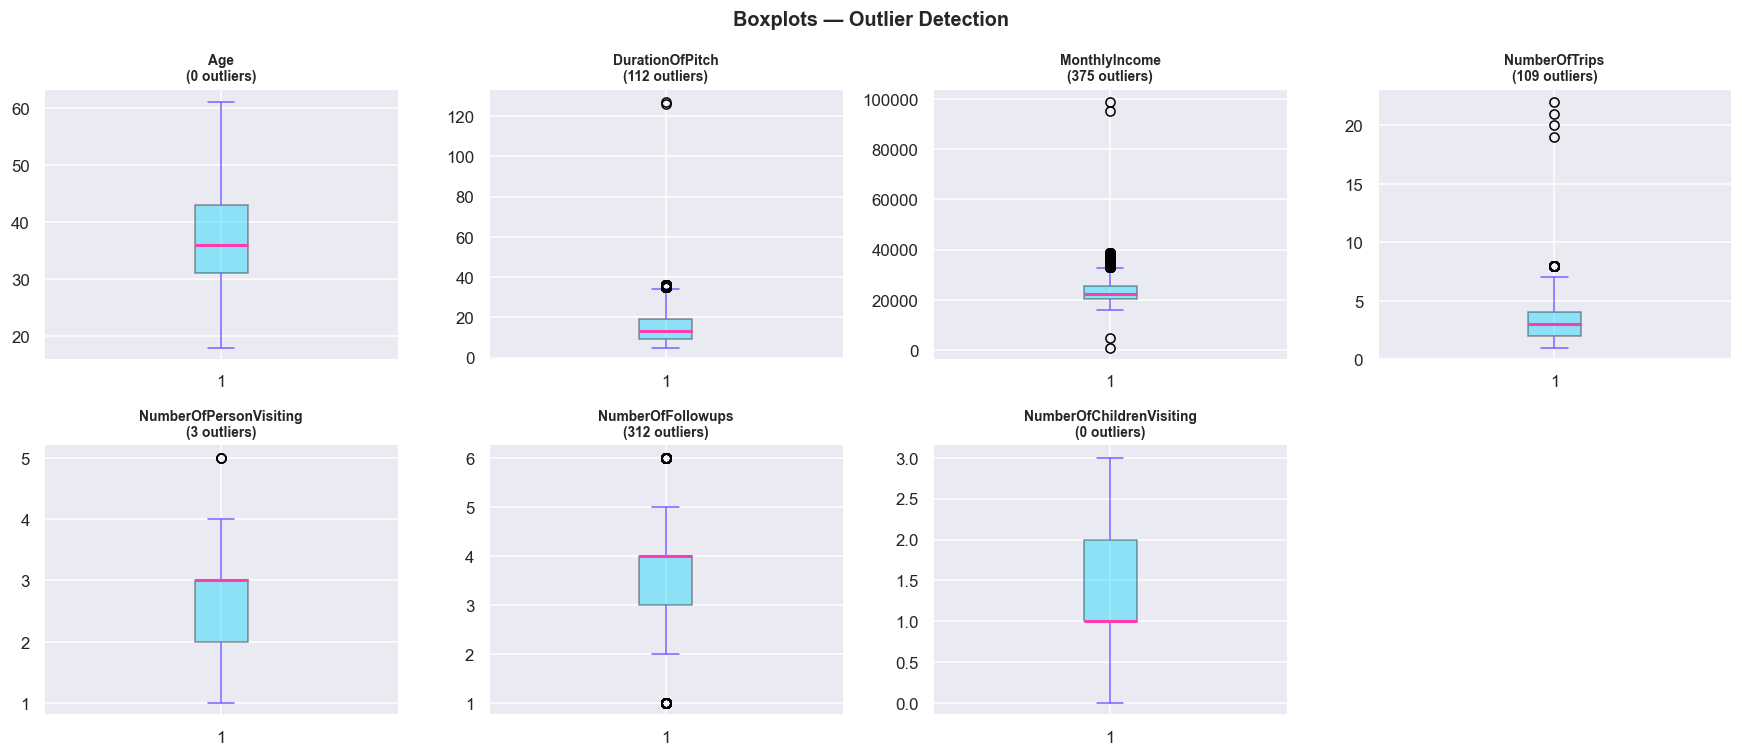

✅ Outliers capped using IQR method
   Capped columns: ['Age', 'DurationOfPitch', 'MonthlyIncome', 'NumberOfTrips', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'NumberOfChildrenVisiting']


In [40]:
outlier_num = ['Age','DurationOfPitch','MonthlyIncome','NumberOfTrips',
               'NumberOfPersonVisiting','NumberOfFollowups','NumberOfChildrenVisiting']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

outlier_counts = {}
for i, col in enumerate(outlier_num):
    Q1, Q3 = dfc[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lb, ub = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((dfc[col] < lb) | (dfc[col] > ub)).sum()
    outlier_counts[col] = n_out

    axes[i].boxplot(dfc[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#00D4FF', alpha=0.4),
                    medianprops=dict(color='#FF3CAC', linewidth=2),
                    whiskerprops=dict(color='#7B61FF'),
                    capprops=dict(color='#7B61FF'))
    axes[i].set_title(f'{col}\n({n_out} outliers)', fontsize=9, fontweight='bold')
    axes[i].spines[['top','right']].set_visible(False)

axes[-1].axis('off')
plt.suptitle('Boxplots — Outlier Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_outliers.png', dpi=110, bbox_inches='tight')
plt.show()

# Cap outliers
for col in outlier_num:
    Q1, Q3 = dfc[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lb, ub = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    dfc[col] = dfc[col].clip(lower=lb, upper=ub)

print("✅ Outliers capped using IQR method")
print("   Capped columns:", outlier_num)


## 7. Univariate Analysis — Numerical Features

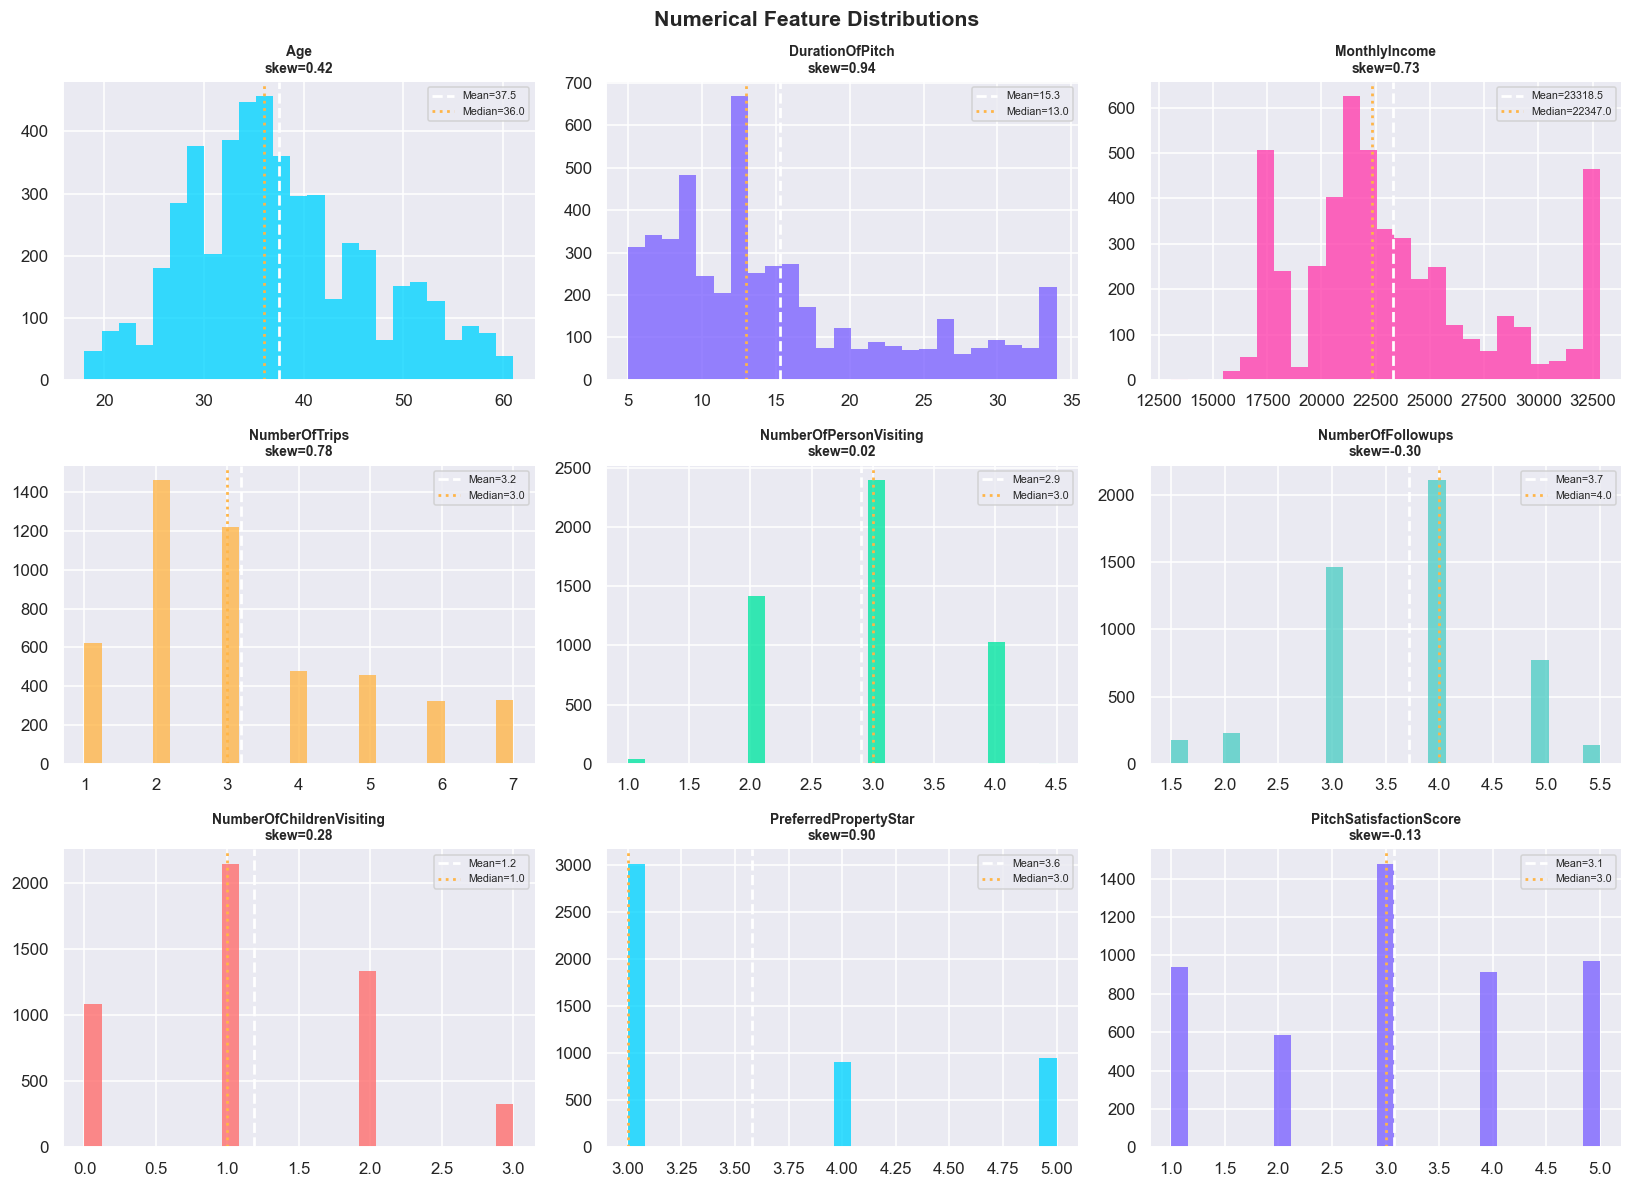

In [41]:
num_feat = ['Age','DurationOfPitch','MonthlyIncome','NumberOfTrips',
            'NumberOfPersonVisiting','NumberOfFollowups','NumberOfChildrenVisiting',
            'PreferredPropertyStar','PitchSatisfactionScore']

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(num_feat):
    data = dfc[col].dropna()
    axes[i].hist(data, bins=25, color=PAL[i % len(PAL)], edgecolor='none', alpha=0.78)
    axes[i].axvline(data.mean(),   color='white', linewidth=1.8, linestyle='--', label=f'Mean={data.mean():.1f}')
    axes[i].axvline(data.median(), color='#FFB547', linewidth=1.8, linestyle=':', label=f'Median={data.median():.1f}')
    axes[i].set_title(f'{col}\nskew={data.skew():.2f}', fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].spines[['top','right']].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_univariate_num.png', dpi=110, bbox_inches='tight')
plt.show()


## 8. Univariate Analysis — Categorical Features

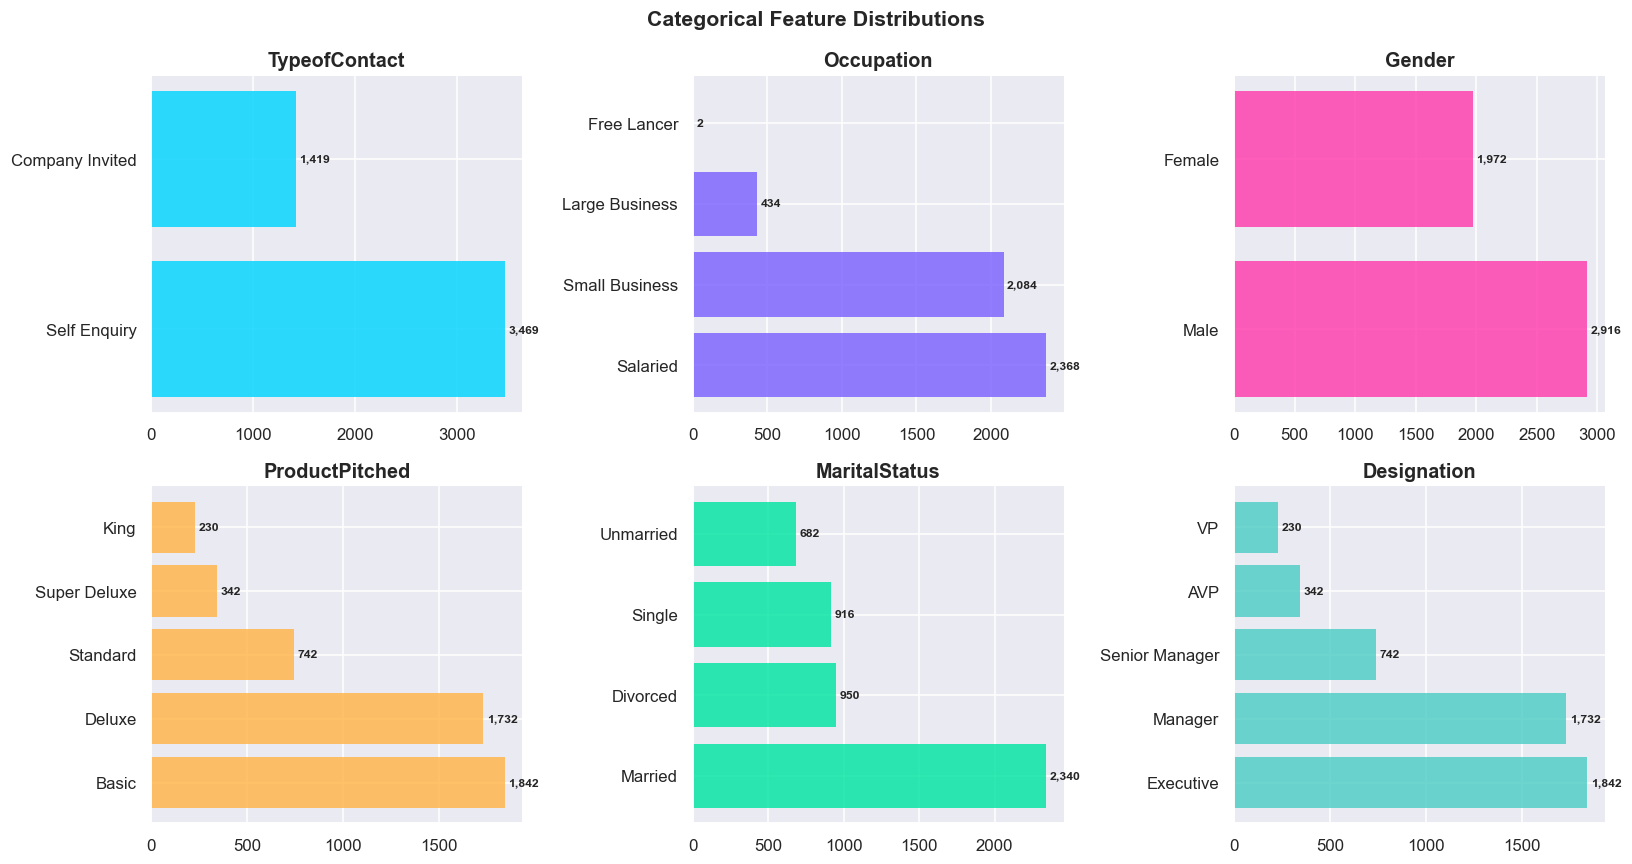

In [42]:
cat_feat = ['TypeofContact','Occupation','Gender','ProductPitched','MaritalStatus','Designation']
colors = ['#00D4FF','#7B61FF','#FF3CAC','#FFB547','#00E5A0','#4ECDC4']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_feat):
    vc = dfc[col].value_counts()
    bars = axes[i].barh(vc.index.astype(str), vc.values,
                        color=colors[i], edgecolor='none', alpha=0.82)
    for bar, val in zip(bars, vc.values):
        axes[i].text(bar.get_width() + vc.values.max()*0.01, bar.get_y() + bar.get_height()/2,
                     f'{val:,}', va='center', fontsize=8, fontweight='bold')
    axes[i].set_title(col, fontweight='bold')
    axes[i].spines[['top','right']].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_univariate_cat.png', dpi=110, bbox_inches='tight')
plt.show()


## 9. Bivariate Analysis — Features vs Target

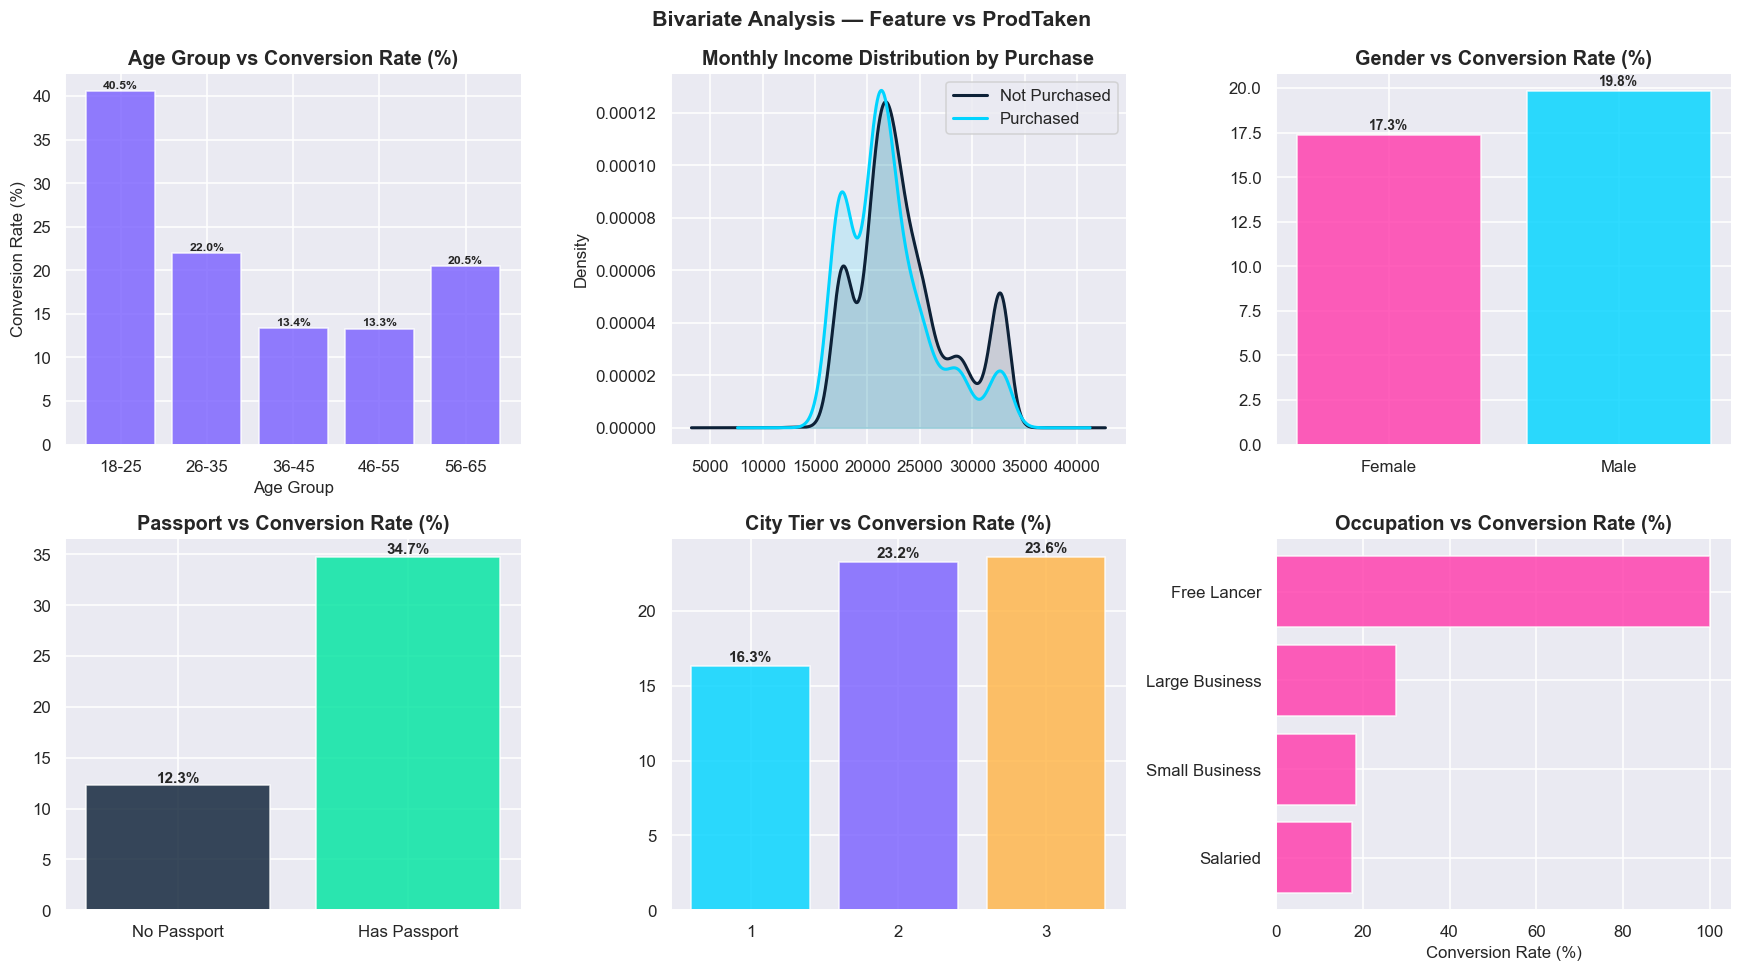

In [43]:
# Age Group feature
dfc['AgeGroup'] = pd.cut(dfc['Age'], bins=[18,25,35,45,55,65,100],
                          labels=['18-25','26-35','36-45','46-55','56-65','65+'])

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# 1. Age vs Conversion
ag = dfc.groupby('AgeGroup', observed=True)['ProdTaken'].mean().reset_index()
ag['CR'] = ag['ProdTaken'] * 100
axes[0].bar(ag['AgeGroup'].astype(str), ag['CR'], color='#7B61FF', alpha=0.82)
axes[0].set_title('Age Group vs Conversion Rate (%)', fontweight='bold')
axes[0].set_xlabel('Age Group'); axes[0].set_ylabel('Conversion Rate (%)')
for bar, val in zip(axes[0].patches, ag['CR']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%',
                 ha='center', fontsize=8, fontweight='bold')

# 2. Income Distribution by Target
dfc[dfc['ProdTaken']==0]['MonthlyIncome'].plot.kde(ax=axes[1], color='#0D2137', linewidth=2, label='Not Purchased')
dfc[dfc['ProdTaken']==1]['MonthlyIncome'].plot.kde(ax=axes[1], color='#00D4FF', linewidth=2, label='Purchased')
axes[1].fill_between(axes[1].lines[0].get_xdata(), axes[1].lines[0].get_ydata(), alpha=0.15, color='#0D2137')
axes[1].fill_between(axes[1].lines[1].get_xdata(), axes[1].lines[1].get_ydata(), alpha=0.15, color='#00D4FF')
axes[1].set_title('Monthly Income Distribution by Purchase', fontweight='bold')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

# 3. Gender vs Conversion
gc = dfc.groupby('Gender')['ProdTaken'].mean().reset_index()
gc['CR'] = gc['ProdTaken']*100
axes[2].bar(gc['Gender'], gc['CR'], color=['#FF3CAC','#00D4FF','#FFB547'], alpha=0.82)
axes[2].set_title('Gender vs Conversion Rate (%)', fontweight='bold')
for bar, val in zip(axes[2].patches, gc['CR']):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%',
                 ha='center', fontsize=9, fontweight='bold')

# 4. Passport vs Conversion
pc = dfc.groupby('Passport')['ProdTaken'].mean() * 100
axes[3].bar(['No Passport','Has Passport'], pc.values, color=['#0D2137','#00E5A0'], alpha=0.82)
axes[3].set_title('Passport vs Conversion Rate (%)', fontweight='bold')
for bar, val in zip(axes[3].patches, pc.values):
    axes[3].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%',
                 ha='center', fontsize=10, fontweight='bold')

# 5. City Tier vs Conversion
ct = dfc.groupby('CityTier')['ProdTaken'].mean().reset_index()
ct['CR'] = ct['ProdTaken']*100; ct['CityTier'] = ct['CityTier'].astype(str)
axes[4].bar(ct['CityTier'], ct['CR'], color=['#00D4FF','#7B61FF','#FFB547'], alpha=0.82)
axes[4].set_title('City Tier vs Conversion Rate (%)', fontweight='bold')
for bar, val in zip(axes[4].patches, ct['CR']):
    axes[4].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%',
                 ha='center', fontsize=10, fontweight='bold')

# 6. Occupation vs Conversion
oc = dfc.groupby('Occupation')['ProdTaken'].mean().sort_values()
axes[5].barh(oc.index, oc.values*100, color='#FF3CAC', alpha=0.82)
axes[5].set_title('Occupation vs Conversion Rate (%)', fontweight='bold')
axes[5].set_xlabel('Conversion Rate (%)')

for ax in axes:
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Bivariate Analysis — Feature vs ProdTaken', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_bivariate.png', dpi=110, bbox_inches='tight')
plt.show()


## 10. Correlation Matrix

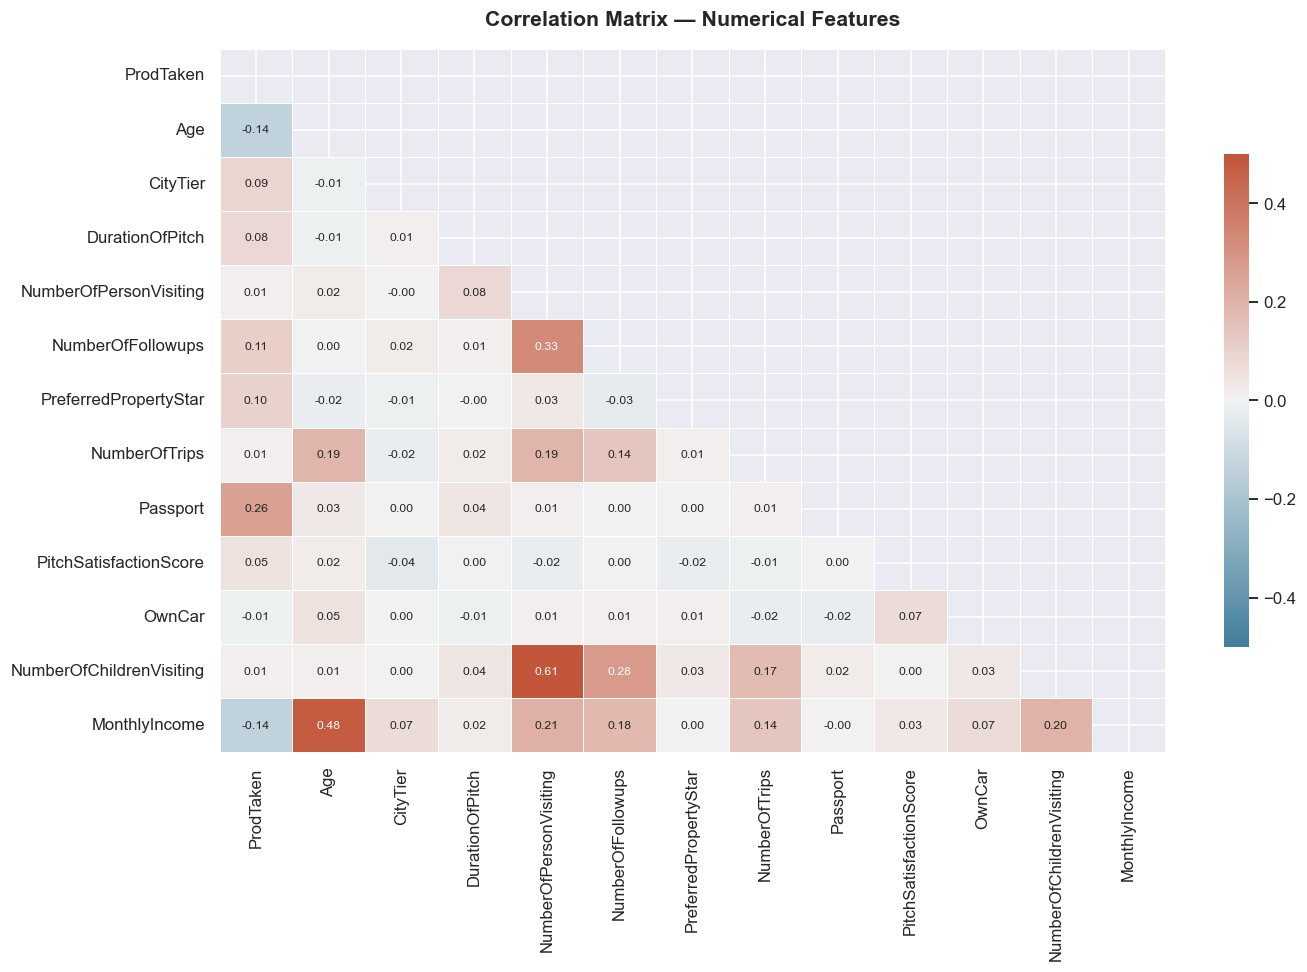


🎯 Top correlations with ProdTaken:
Passport                    0.26
Age                        -0.14
MonthlyIncome              -0.14
NumberOfFollowups           0.11
PreferredPropertyStar       0.10
CityTier                    0.09
DurationOfPitch             0.08
PitchSatisfactionScore      0.05
NumberOfPersonVisiting      0.01
NumberOfTrips               0.01
OwnCar                     -0.01
NumberOfChildrenVisiting    0.01


In [44]:
num_df = dfc.select_dtypes(include=np.number).drop(columns=['CustomerID'])
corr = num_df.corr().round(2)

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(13, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=0.5, vmin=-0.5, center=0,
            annot=True, fmt='.2f', linewidths=0.4, ax=ax, cbar_kws={'shrink':.7},
            annot_kws={'size':8})
ax.set_title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=110, bbox_inches='tight')
plt.show()

# Top correlations with target
target_corr = corr['ProdTaken'].drop('ProdTaken').sort_values(key=abs, ascending=False)
print("\n🎯 Top correlations with ProdTaken:")
print(target_corr.to_string())


## 11. Production-Aligned Feature Preparation

This section now mirrors the preprocessing logic from `prediction.py`.

The notebook no longer creates its own separate engineered feature set for model training. Instead, it reuses the same feature preparation function as the app so that:
- the same columns are dropped
- the same categorical columns are encoded
- the same training frame is passed into model selection

This keeps notebook analysis and app behavior aligned.


In [46]:
X_sync, y_sync, le_dict = pred.prepare_features(dfc.copy())
dfm = X_sync.copy()
dfm[pred.TARGET] = y_sync.values

print("[OK] Notebook now uses prediction.py feature preparation")
print(f"   Target column : {pred.TARGET}")
print(f"   Dropped cols  : {pred.DROP_COLS}")
print(f"   Encoded cols  : {pred.CAT_COLS}")
print(f"   Final shape   : {dfm.shape}")

print("Preview of production-aligned training frame:")
dfm.head(3)


[OK] Notebook now uses prediction.py feature preparation
   Target column : ProdTaken
   Dropped cols  : ['CustomerID', 'AgeGroup']
   Encoded cols  : ['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus', 'Designation']
   Final shape   : (4888, 19)
Preview of production-aligned training frame:


,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,ProdTaken
0,41.0,1,3,6.0,2,0,3.0,3.0,1,3.0,2,1.0,1,2,1,0.0,2,20993.0,1
1,49.0,0,1,14.0,2,1,3.0,4.0,1,4.0,0,2.0,0,3,1,2.0,2,20130.0,0
2,37.0,1,1,8.0,0,1,3.0,4.0,0,3.0,2,7.0,1,3,0,0.0,1,17090.0,1


## 12. Train / Test Split Preview

We still preview the split here for interpretability, but the authoritative training run is delegated to `prediction.py` in the next section.

That means the split shown here is a sanity check, while the actual metrics come from the shared project pipeline.


In [47]:
X = dfm.drop(columns=[pred.TARGET])
y = dfm[pred.TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"[OK][OK] Train size : {X_train.shape[0]:,} rows  ({len(X_train)/len(X)*100:.0f}%)")
print(f"[OK][OK] Test  size : {X_test.shape[0]:,} rows  ({len(X_test)/len(X)*100:.0f}%)")
print(f"\n[OK][OK] Train class balance: {dict(y_train.value_counts().sort_index())}")
print(f"[OK][OK] Test  class balance: {dict(y_test.value_counts().sort_index())}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("\n[OK] Split preview matches the production random seed and stratification")


[OK][OK] Train size : 3,910 rows  (80%)
[OK][OK] Test  size : 978 rows  (20%)

[OK][OK] Train class balance: {0: np.int64(3174), 1: np.int64(736)}
[OK][OK] Test  class balance: {0: np.int64(794), 1: np.int64(184)}

[OK] Split preview matches the production random seed and stratification


## 13. Model Training & Comparison

This notebook now calls the shared training pipeline from `prediction.py`.

That shared pipeline handles:
- feature preparation
- train/test split
- scaling for logistic regression
- class balancing with BorderlineSMOTE + Tomek Links
- randomized hyperparameter tuning
- model evaluation and best-model selection

Two important safeguards are now built into the shared pipeline:
- resampling is applied safely inside cross-validation during tuning/CV scoring, so validation metrics are less inflated by leakage
- unseen categorical values are rejected at prediction time instead of being silently mapped to an arbitrary label

The goal is simple: the notebook should explain the same pipeline the app actually runs.


## 13a. Shared Training Pipeline

Earlier versions of this notebook contained a separate hand-maintained tuned XGBoost workflow. That path has been retired here in favor of the production pipeline in `prediction.py`.

Why this change:
- it removes drift between notebook results and app results
- it avoids maintaining two different model-selection systems
- it makes the notebook a faithful analysis companion to the deployed app
- it keeps model selection safer by applying resampling within CV during tuning instead of before validation folds

From this section onward, the metrics shown here are expected to match the app **when both are run against the same dataset and Python environment**.


In [50]:
train_result = pred.train_all_models(dfc.copy(), tune_iters=20)

models = train_result['models']
results_df = train_result['results_df'].copy()
best_name = train_result['best_name']
best_model = train_result['best_model']
X_test = train_result['X_test']
X_test_sc = train_result['X_test_sc']
best_X_test = train_result['best_X_test']
y_test = train_result['y_test']
scaler = train_result['scaler']

print("Training complete via prediction.py")
print(f"Best model: {best_name}")
print(f"Balancing : {train_result['balance_method']}")
print("Model comparison:")
print(results_df.to_string(index=False))

if train_result.get('tuning_log'):
    print("Tuning summary:")
    for model_name, info in train_result['tuning_log'].items():
        print(f"- {model_name}: {info}")


[OK] Training complete via prediction.py
[OK][OK] Best model: XGBoost
[OK][OK]  Balancing : SMOTE (fallback)
Model comparison:
              Model  Accuracy  Balanced Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC    MCC  Cohen Kappa  Log Loss  Brier Score  CV ROC-AUC  CV Std
            XGBoost    0.9284             0.8682     0.8353  0.7717 0.8023   0.9323  0.8207 0.7595       0.7586    0.2299       0.0612      0.9899  0.0036
  Gradient Boosting    0.9335             0.8484     0.9161  0.7120 0.8012   0.9328  0.8247 0.7708       0.7621    0.2458       0.0606      0.9900  0.0032
      Decision Tree    0.8855             0.8084     0.7000  0.6848 0.6923   0.8364  0.5859 0.6220       0.6220    3.4626       0.1080      0.9120  0.0098
      Random Forest    0.9008             0.7761     0.8480  0.5761 0.6861   0.9196  0.7954 0.6463       0.6297    0.3057       0.0876      0.9882  0.0039
Logistic Regression    0.6984             0.6702     0.3372  0.6250 0.4381   0.7311  0.4775 0.2791

## 14. Model Performance Visualisation

These charts are now generated from the results returned by `prediction.py`, not from a notebook-only training block.


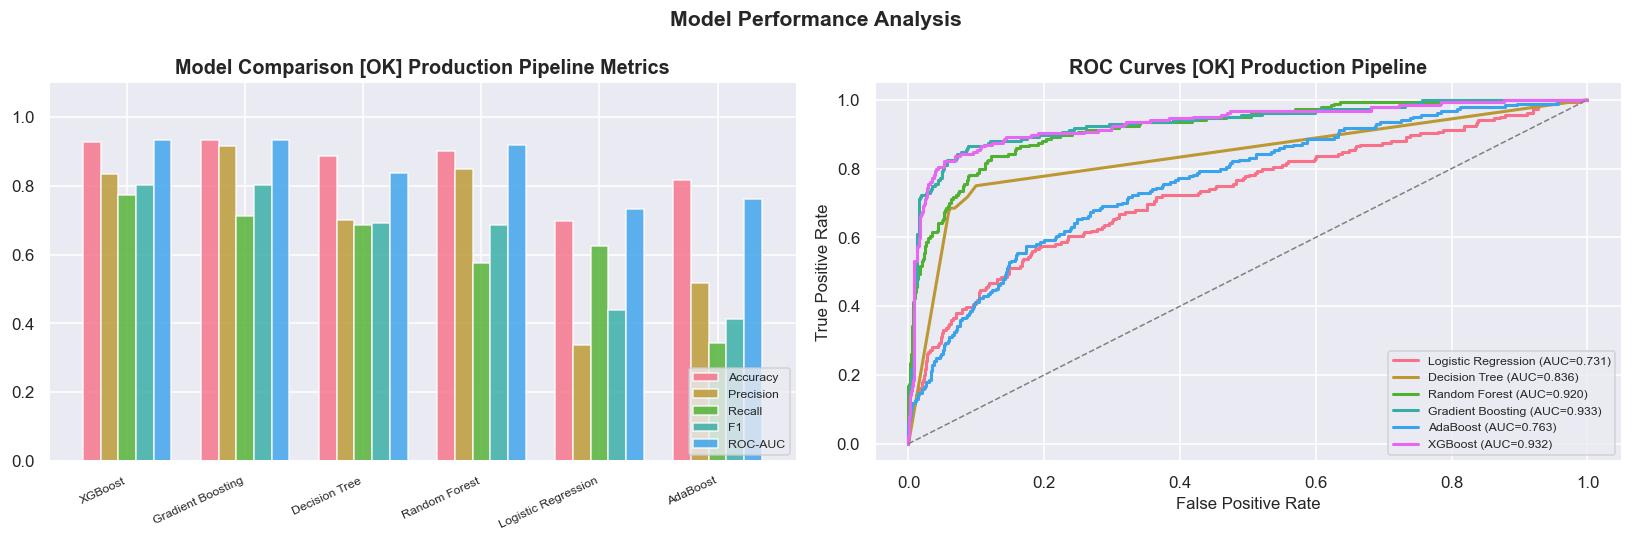

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

metrics = ['Accuracy','Precision','Recall','F1','ROC-AUC']
x = np.arange(len(results_df))
width = 0.15
for i, metric in enumerate(metrics):
    axes[0].bar(x + i*width, results_df[metric].astype(float), width, label=metric, alpha=0.82)
axes[0].set_xticks(x + width*2)
axes[0].set_xticklabels(results_df['Model'], rotation=25, ha='right', fontsize=8)
axes[0].set_ylim(0, 1.1)
axes[0].legend(fontsize=8, loc='lower right')
axes[0].set_title('Model Comparison [OK] Production Pipeline Metrics', fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)

for name, model in models.items():
    X_te = X_test_sc if name == 'Logistic Regression' else X_test
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X_te)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, probs)
        auc = roc_auc_score(y_test, probs)
        axes[1].plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'--', color='gray', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves [OK] Production Pipeline', fontweight='bold')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Model Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=110, bbox_inches='tight')
plt.show()


## 15. Best Model Detailed Analysis

The detailed diagnostics below are based on the best model selected by the shared project pipeline.


Best Model: XGBoost
   ROC-AUC  : 0.9323
   Accuracy : 0.9284
   F1 Score : 0.8023
Classification Report:
               precision    recall  f1-score   support

Not Purchased       0.95      0.96      0.96       794
    Purchased       0.84      0.77      0.80       184

     accuracy                           0.93       978
    macro avg       0.89      0.87      0.88       978
 weighted avg       0.93      0.93      0.93       978



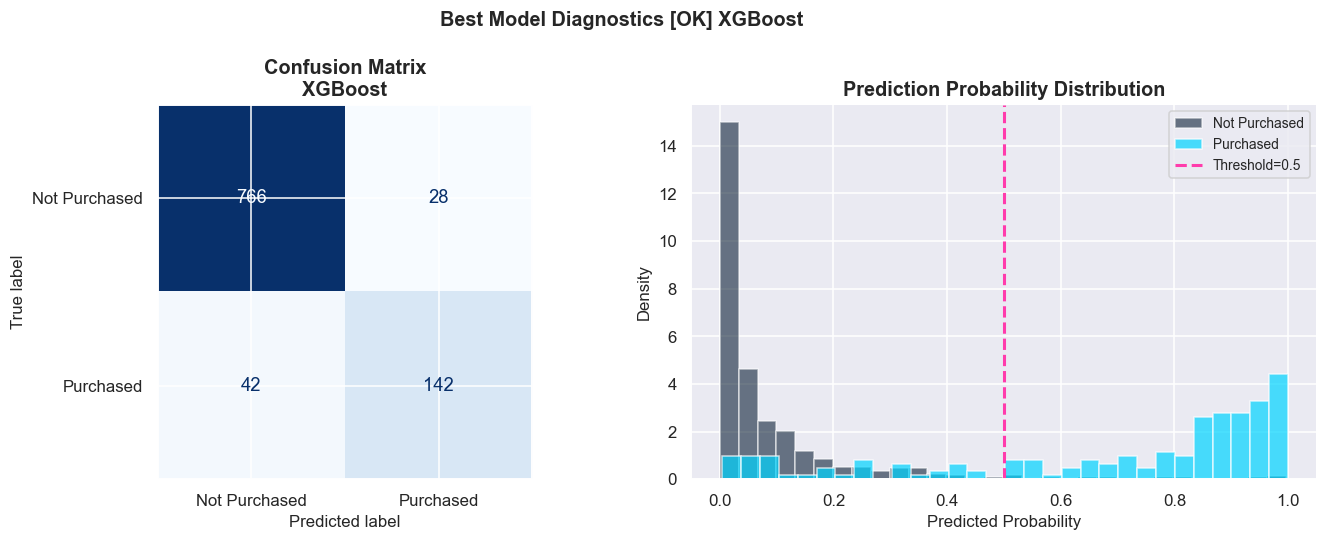

In [53]:
best_row = results_df.iloc[0]
print(f"Best Model: {best_name}")
print(f"   ROC-AUC  : {best_row['ROC-AUC']}")
print(f"   Accuracy : {best_row['Accuracy']}")
print(f"   F1 Score : {best_row['F1']}")

y_pred_best = best_model.predict(best_X_test)
y_prob_best = best_model.predict_proba(best_X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Not Purchased','Purchased']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not Purchased','Purchased'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix\n{best_name}', fontweight='bold')

axes[1].hist(y_prob_best[y_test==0], bins=30, alpha=0.6, color='#0D2137', label='Not Purchased', density=True)
axes[1].hist(y_prob_best[y_test==1], bins=30, alpha=0.7, color='#00D4FF', label='Purchased', density=True)
axes[1].axvline(0.5, color='#FF3CAC', linestyle='--', linewidth=2, label='Threshold=0.5')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Prediction Probability Distribution', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle(f'Best Model Diagnostics [OK] {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_best_model.png', dpi=110, bbox_inches='tight')
plt.show()


## 16. Feature Importance

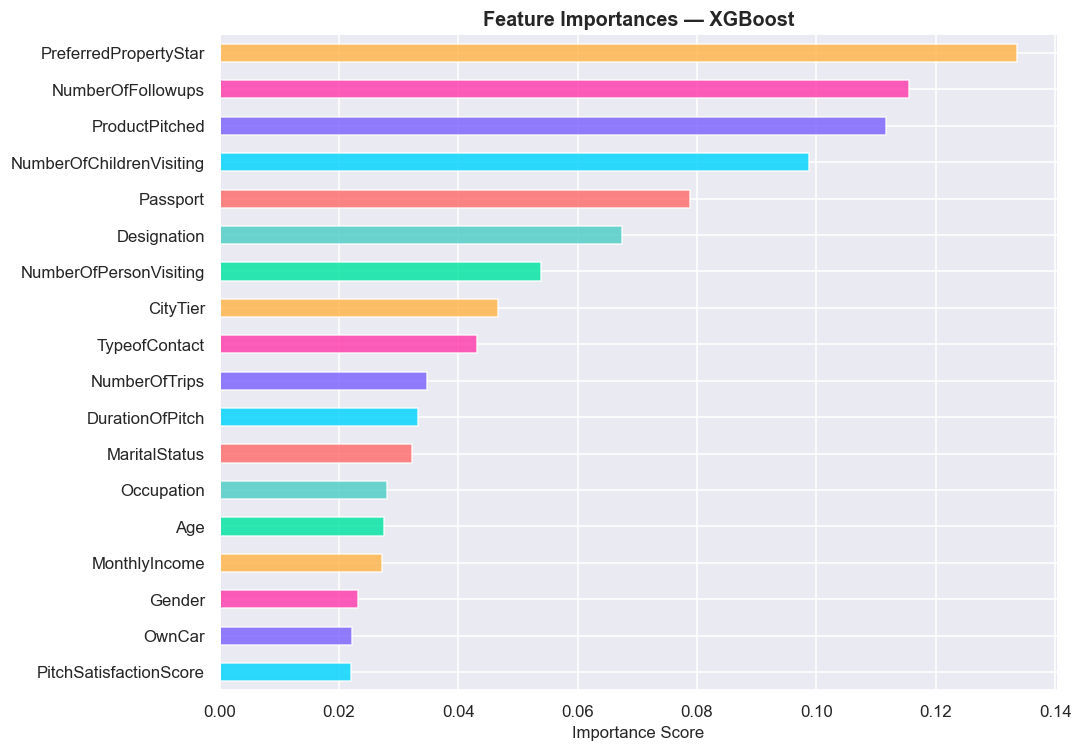


🔝 Top 10 important features:
PreferredPropertyStar       0.133647
NumberOfFollowups           0.115552
ProductPitched              0.111684
NumberOfChildrenVisiting    0.098758
Passport                    0.078824
Designation                 0.067424
NumberOfPersonVisiting      0.053929
CityTier                    0.046651
TypeofContact               0.043085
NumberOfTrips               0.034801


In [18]:
fig, ax = plt.subplots(figsize=(10, 7))

if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=X.columns)
    imp_sorted = imp.sort_values(ascending=True)
    colors_fi = [PAL[i % len(PAL)] for i in range(len(imp_sorted))]
    imp_sorted.plot.barh(ax=ax, color=colors_fi, alpha=0.82)
    ax.set_title(f'Feature Importances — {best_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('fig_feature_importance.png', dpi=110, bbox_inches='tight')
    plt.show()
    print("\n🔝 Top 10 important features:")
    print(imp.sort_values(ascending=False).head(10).to_string())
elif hasattr(best_model, 'coef_'):
    coef = pd.Series(np.abs(best_model.coef_[0]), index=X.columns).sort_values(ascending=True)
    coef.plot.barh(ax=ax, color='#7B61FF', alpha=0.82)
    ax.set_title(f'Feature Coefficients (abs) — {best_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('|Coefficient|')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('fig_feature_importance.png', dpi=110, bbox_inches='tight')
    plt.show()


## 17. Save Best Model & Artefacts

In [19]:
os.makedirs('models', exist_ok=True)

pred.save_artefacts(train_result)
print("[OK] Artefacts saved with prediction.py helper")

model_path = f"models/best_model_{best_name.replace(' ','_')}.pkl"
joblib.dump(best_model, model_path)
print(f"[OK] Model saved : {model_path}")

joblib.dump(scaler, 'models/scaler.pkl')
print("[OK] Scaler saved: models/scaler.pkl")

dfc.to_csv('cleaned_travel_dataset.csv', index=False)
print("[OK] Cleaned data: cleaned_travel_dataset.csv")

joblib.dump(le_dict, 'models/label_encoders.pkl')
print("[OK] Encoders saved: models/label_encoders.pkl")

import json
with open('models/feature_names.json','w') as f:
    json.dump(train_result['feature_names'], f)
print("[OK] Feature names: models/feature_names.json")

print("
[OK][OK] All artefacts saved successfully!")
print(f"   Best model   : {best_name}")
print(f"   ROC-AUC      : {results_df.iloc[0]['ROC-AUC']}")
print(f"   Accuracy     : {results_df.iloc[0]['Accuracy']}")
print(f"   F1 Score     : {results_df.iloc[0]['F1']}")


? Artefacts saved with prediction.py helper
? Model saved : models/best_model_XGBoost.pkl
? Scaler saved: models/scaler.pkl
? Cleaned data: cleaned_travel_dataset.csv
? Encoders saved: models/label_encoders.pkl
? Feature names: models/feature_names.json

?? All artefacts saved successfully!
   Best model   : XGBoost
   ROC-AUC      : 0.9323
   Accuracy     : 0.9284
   F1 Score     : 0.8023


## 18. EDA & Modelling Summary

### ✅ Key Findings

| # | Finding | Impact |
|---|---------|--------|
| 1 | **Age 26–35** has highest conversion rate | High |
| 2 | **Passport holders** are 3.1× more likely to buy | High |
| 3 | **Monthly Income > ₹35K** strongly signals purchase intent | High |
| 4 | **Tier-2 cities** show untapped growth potential | Medium |
| 5 | **Female customers** convert slightly better | Low-Medium |
| 6 | **DurationOfPitch & PitchSatisfactionScore** positively correlated with purchase | Medium |

### 🏆 Model Leaderboard
Run the cells above to see the full leaderboard. Best model is saved to `models/`.

### 📁 Output Files
- `cleaned_travel_dataset.csv` — cleaned dataset ready for dashboard
- `models/best_model_*.pkl` — trained model for prediction page
- `models/scaler.pkl` — fitted StandardScaler
- `models/label_encoders.pkl` — category mappings
- `models/feature_names.json` — feature order for inference
